## Trabalho Final de Modelos de Regressão

#### Aluno : Renan Lemes Leepkaln

#### Dados utilizados **Medical Cost Personal Datasets**

#### Descrição dos dados 
* age - Idade
* sex - sexo 
* bmi - indice de massa corporal
* children - quantidade de filhos
* smoker - se a pessoa é fumante 
* region - região 
* charges - custos médico associado a cada individuo

#### Situalizando o problema
Temos dados relacionado a um hospital e queremos prever os gastos para gerar um bom controle e uma administração melhor com base nas colunas do dataframe.


#### Modelo utilizado
##### definida por :
$$
    g(\mu_i) = \beta_0 + \beta_1 x_{ji} + \beta_2 x_{i2} + ... + \beta_p x_{ip}
$$
* $g(\cdot)$ é a função ligação
    * $g(\mu) = \mu_i^{-1}$ função inversa (ligação canonica)
    * $g(\mu) = log(\mu_i)$ função logaritimica (efeitos multiplicativos)
    * $g(\mu) = \mu_i$ função identidade (efeitos aditivos)
* $\mu$ é a média da distribuição de gammma
* $\beta_0, \beta_1 ..., \beta_p$ são coeficientes do modelo 
* $x_1, x_2, ..., x_p$ são os preditores do modelo

In [53]:
## libs para tratar os dados
import pandas as pd 
import numpy as np

## libs para plotar graficos
import matplotlib.pyplot as plt
import seaborn as sns

## Libs para rodar os modelos 
import statsmodels.api as sm
from sklearn.model_selection import train_test_split


import warnings
warnings.filterwarnings('ignore')

In [54]:
df = pd.read_csv("insurance.csv")

In [55]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


#### Processamento dos dados 

In [56]:
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [57]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


Notei aqui que sex,  e a variavel smoker são binárias então posso atribuilas 1 e 0 para usar no modelo depois.

In [59]:
df.sex = df.sex.map(lambda x: 1 if x == "male" else 0) ## Aqui colocamos para masculino 1 e feminino 0 
df.smoker = df.smoker.map(lambda x: 1 if x == 'yes' else 0) ## Aqui estamos fazendo a mesma coisa porem para fumantes

In [60]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,southwest,16884.92400
1,18,1,33.770,1,0,southeast,1725.55230
2,28,1,33.000,3,0,southeast,4449.46200
3,33,1,22.705,0,0,northwest,21984.47061
4,32,1,28.880,0,0,northwest,3866.85520


Preferi optar por essa abordagem por conta de dimensionalidade do modelo caso ficaria mutio complexo com todas dummies, assim podemos fazer so a variável region como dummies

In [61]:
df = pd.get_dummies(df, columns=["region"])

df.head()

,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,False,False,False,True
1,18,1,33.770,1,0,1725.55230,False,False,True,False
2,28,1,33.000,3,0,4449.46200,False,False,True,False
3,33,1,22.705,0,0,21984.47061,False,True,False,False
4,32,1,28.880,0,0,3866.85520,False,True,False,False


In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               1338 non-null   int64  
 1   sex               1338 non-null   int64  
 2   bmi               1338 non-null   float64
 3   children          1338 non-null   int64  
 4   smoker            1338 non-null   int64  
 5   charges           1338 non-null   float64
 6   region_northeast  1338 non-null   bool   
 7   region_northwest  1338 non-null   bool   
 8   region_southeast  1338 non-null   bool   
 9   region_southwest  1338 non-null   bool   
dtypes: bool(4), float64(2), int64(4)
memory usage: 68.1 KB


Como visto antes não necessitamos fazer nenhuma alteração nos dados sem valores faltantes e sem valores vazios.

#### Análise descritiva 

In [63]:
df.describe()

,age,sex,bmi,children,smoker,charges
count,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,0.505232,30.663397,1.094918,0.204783,13270.422265
std,14.049960,0.500160,6.098187,1.205493,0.403694,12110.011237
min,18.000000,0.000000,15.960000,0.000000,0.000000,1121.873900
25%,27.000000,0.000000,26.296250,0.000000,0.000000,4740.287150
50%,39.000000,1.000000,30.400000,1.000000,0.000000,9382.033000
75%,51.000000,1.000000,34.693750,2.000000,0.000000,16639.912515
max,64.000000,1.000000,53.130000,5.000000,1.000000,63770.428010


In [64]:
labels = ["male", "female"]
size = [sum(df.sex == 1), sum(df.sex == 0)]

In [65]:
size

[676, 662]

In [75]:
plt.style.use("default")

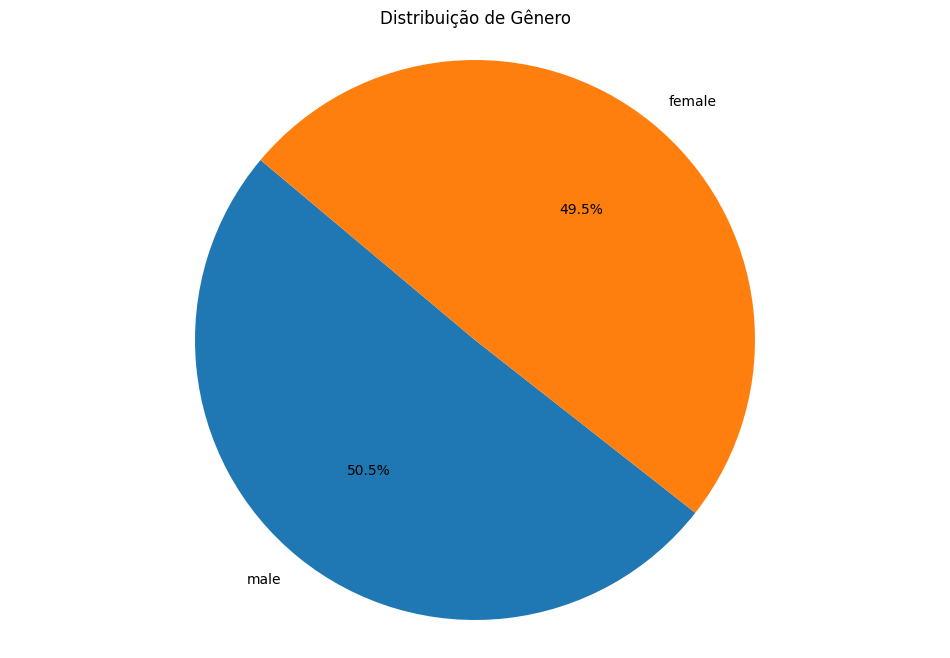

In [76]:
# Criar o gráfico de pizza
plt.figure(figsize=(12, 8))  # Define o tamanho da figura (opcional)
plt.pie(
    size, labels=labels, autopct="%1.1f%%", startangle=140
)  # Cria o gráfico de pizza com rótulos
plt.title("Distribuição de Gênero")  # Define o título do gráfico
plt.axis("equal")  # Faz com que o gráfico de pizza seja circular
plt.show()  # Mostra o gráfico

Aqui deu para notar que nossa base de dados está bem distribuida. Vamos fazer o mesmo para fumantes e não fumantes.

In [77]:
labels = ['fumantes', 'não fumantes']
size = [sum(df.smoker == 1), sum(df.smoker == 0)]


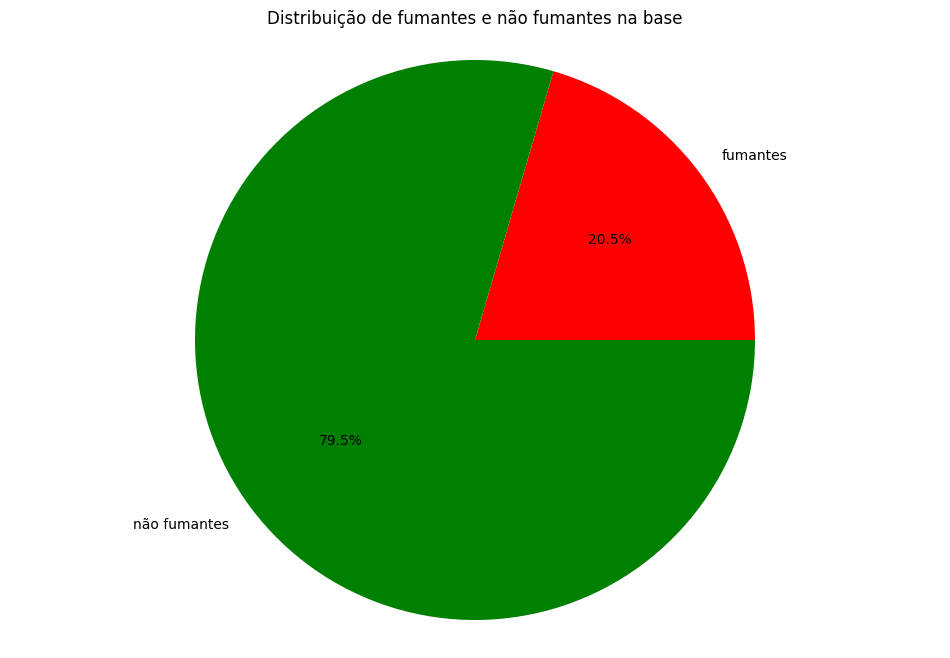

In [84]:

plt.figure(figsize=(12, 8))  
plt.pie(
    size, labels=labels, autopct="%1.1f%%", colors=['red', 'green']
) 
plt.title("Distribuição de fumantes e não fumantes na base")
plt.axis("equal")
plt.show()

Aqui notamos uma grande diferença na distribuição em não fumantes. 